**Index No.:** 230280L  
**Name:** J. A. P. R. Jayasinghe  

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

In [22]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

**Question 1**

In [7]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)

    im_float = im.astype(np.float64)
    out = np.zeros_like(im_float)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, no input range to map

        mask = (im_float >= x0) & (im_float < x1)
        slope = (y1 - y0) / (x1 - x0)
        out[mask] = y0 + slope * (im_float[mask] - x0)

    out[im_float == breakpoints[-1, 0]] = breakpoints[-1, 1]
    out = np.clip(out, 0, 255).astype(np.uint8)

    # Build a 256-point curve for plotting only
    all_x = np.arange(256, dtype=np.float64)
    curve = np.zeros_like(all_x)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        mask = (all_x >= x0) & (all_x < x1)
        slope = (y1 - y0) / (x1 - x0)
        curve[mask] = y0 + slope * (all_x[mask] - x0)
    curve[-1] = breakpoints[-1, 1]

    return out, curve

In [ ]:
img = cv2.imread('Images/img1.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [50, 100],
    [100, 175],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed, curve = intensity_transform(img, breakpoints)

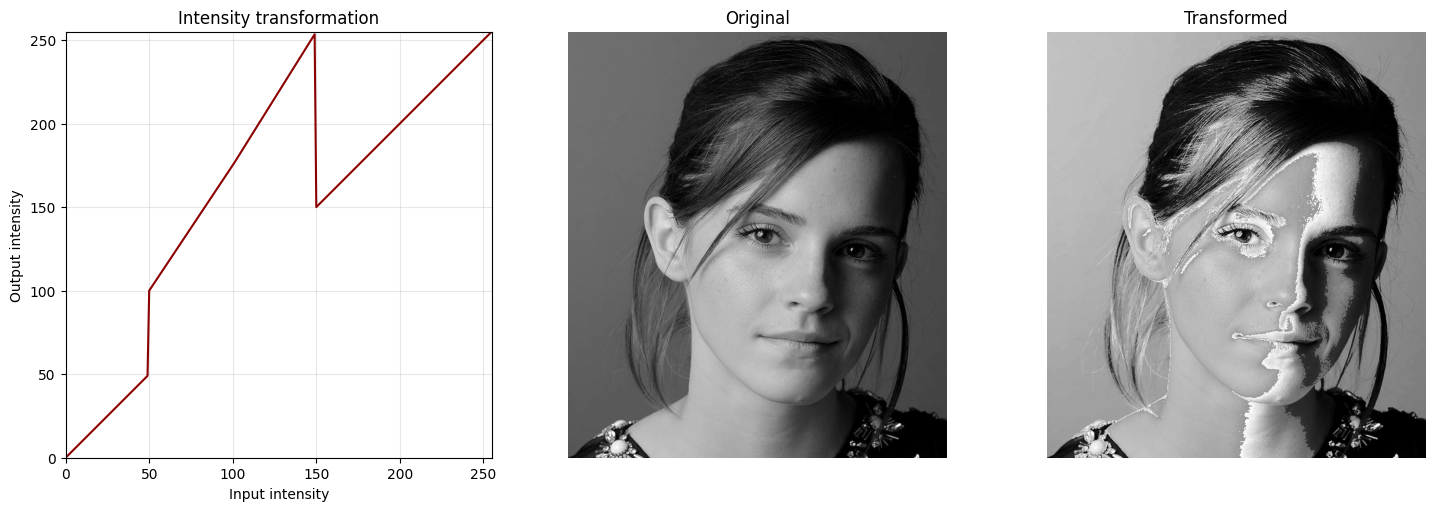

In [9]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), curve, color='darkred')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 2**

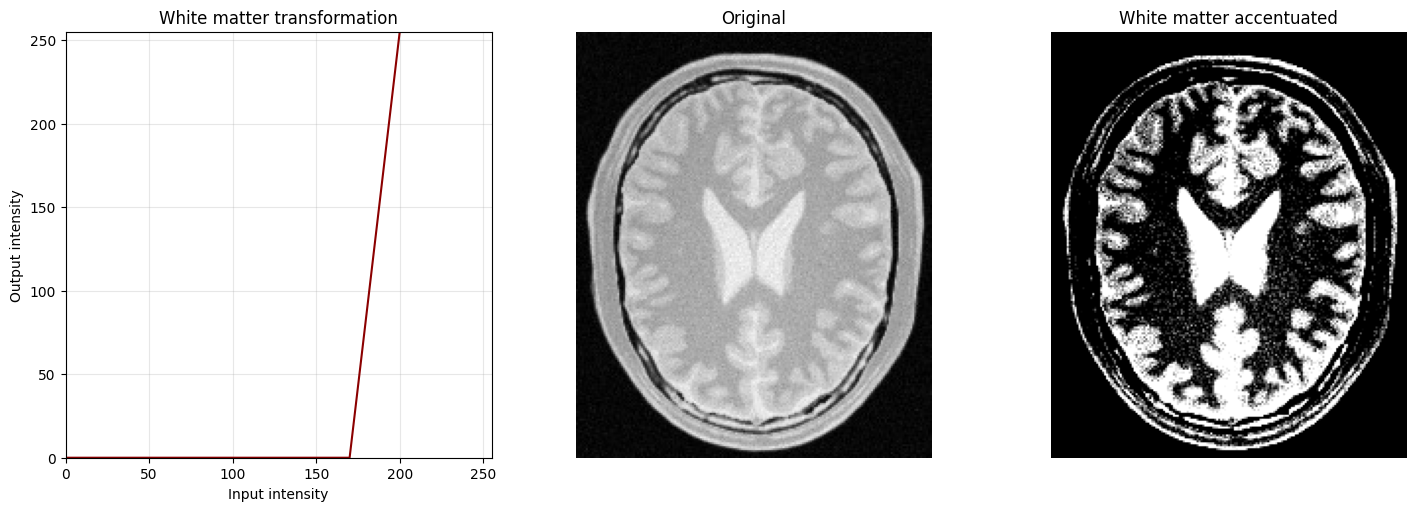

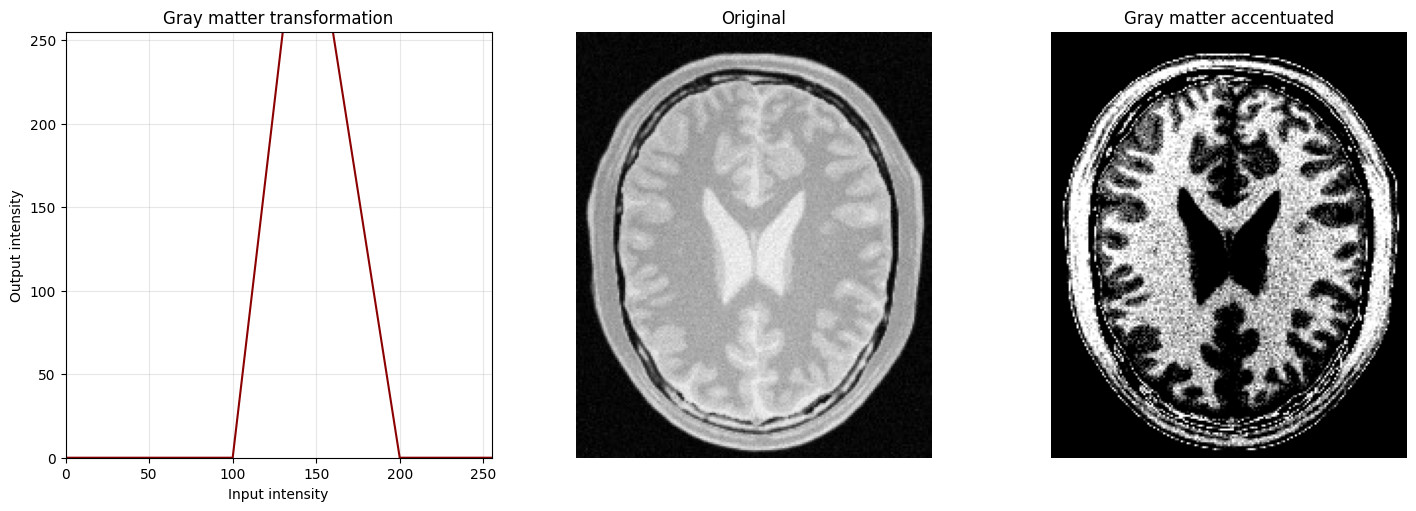

In [ ]:
brain = cv2.imread('Images/img2.jpeg', cv2.IMREAD_GRAYSCALE)

# Transform all white matter to maximum intensity.
white_matter_breakpoints = [
    [0, 0],
    [170, 0],
    [200, 255],
    [255, 255],
]

# Tranform all gray matter to maximum intensity
gray_matter_breakpoints = [
    [0, 0],
    [100, 0],
    [130, 255],
    [160, 255],
    [200, 0],
    [255, 0],
]

white_out, white_curve = intensity_transform(brain, white_matter_breakpoints)
gray_out, gray_curve = intensity_transform(brain, gray_matter_breakpoints)

# White matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), white_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('White matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

# Gray matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), gray_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gray matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 3**

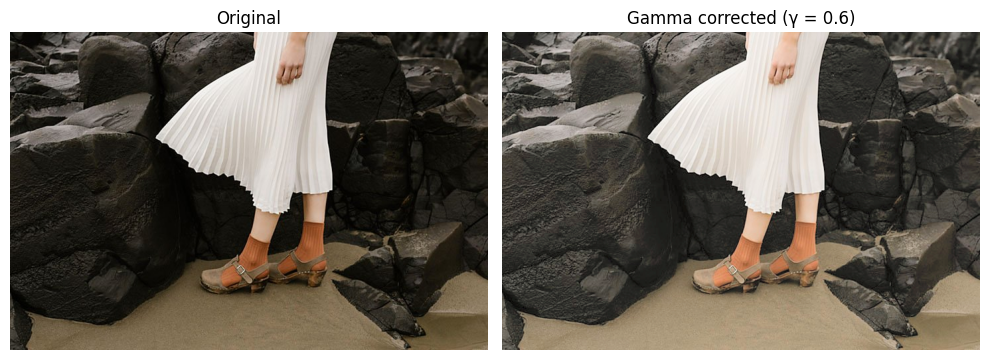

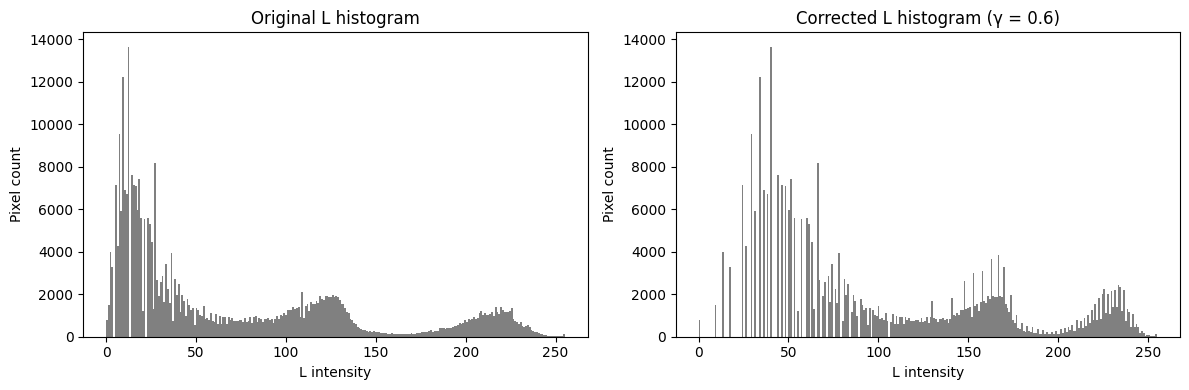

In [12]:
img_bgr = cv2.imread('Images/img3.jpeg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to L*a*b* 
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Apply gamma correction to the L plane
gamma = 0.6

L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])
img_corrected_bgr = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
img_corrected_rgb = cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB)

# Original Image vs Gamma Corrected Image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma corrected (γ = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Histograms of the L plane
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[0].set_xlabel('L intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ = {gamma})')
axes[1].set_xlabel('L intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()

**Question 4**

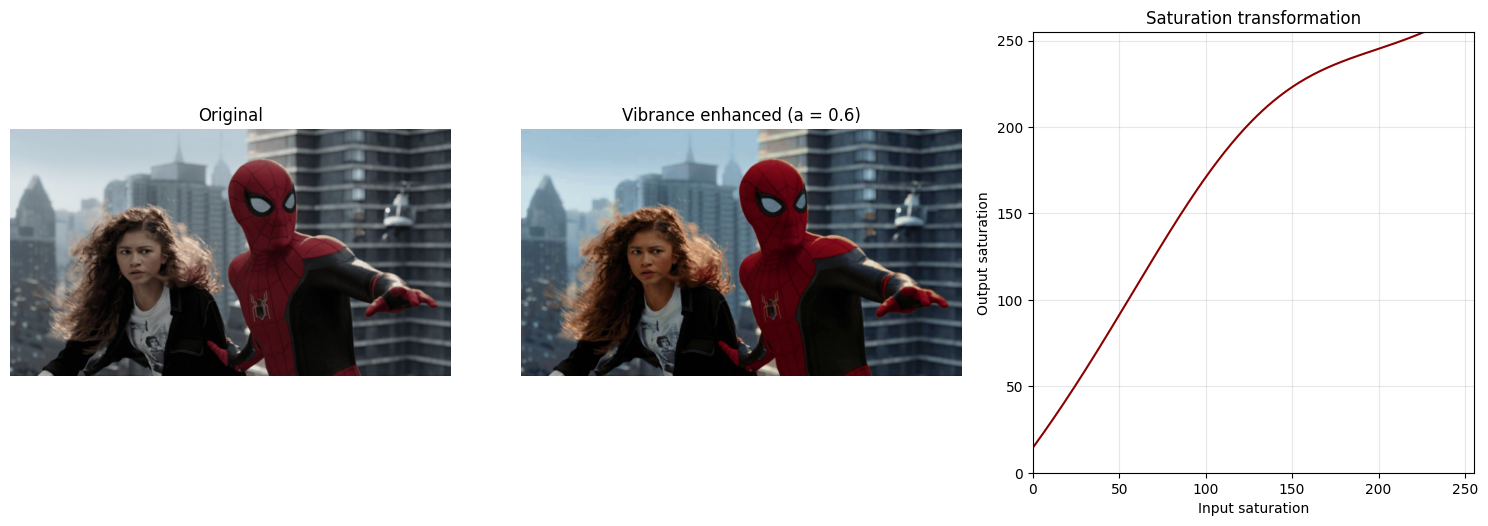

In [13]:
img_bgr = cv2.imread('Images/img4.jpeg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# (a) Split into hue, saturation, value planes
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# (b) Vibrance transformation on the saturation plane
sigma = 70

def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255)

# (c) Pick a
a = 0.6  

s_boosted = vibrance_transform(s, a, sigma).astype(np.uint8)

# (d) Recombine the three planes
hsv_boosted = cv2.merge([h, s_boosted, v])
img_boosted_bgr = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)
img_boosted_rgb = cv2.cvtColor(img_boosted_bgr, cv2.COLOR_BGR2RGB)

# (e) Display original, vibrance-enhanced, and the transformation curve
x_vals = np.arange(256)
curve = vibrance_transform(x_vals, a, sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_boosted_rgb)
axes[1].set_title(f'Vibrance enhanced (a = {a})')
axes[1].axis('off')

axes[2].plot(x_vals, curve, color='darkred')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Saturation transformation')
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

**Question 5**

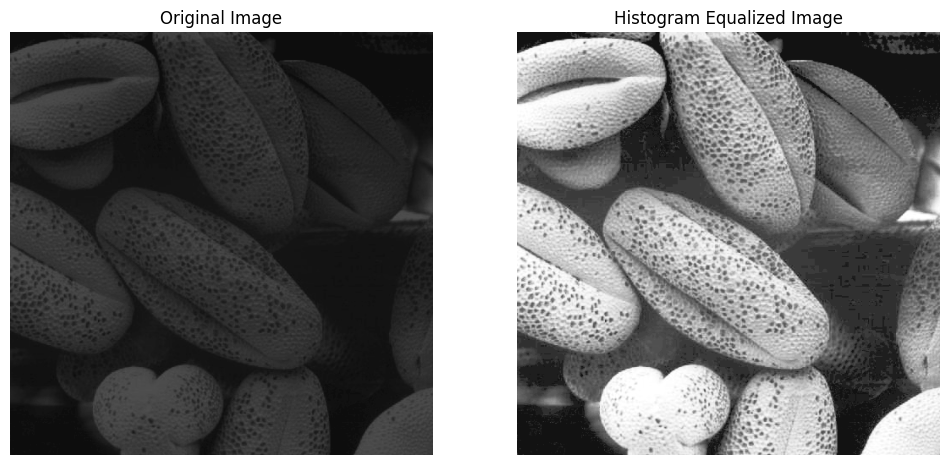

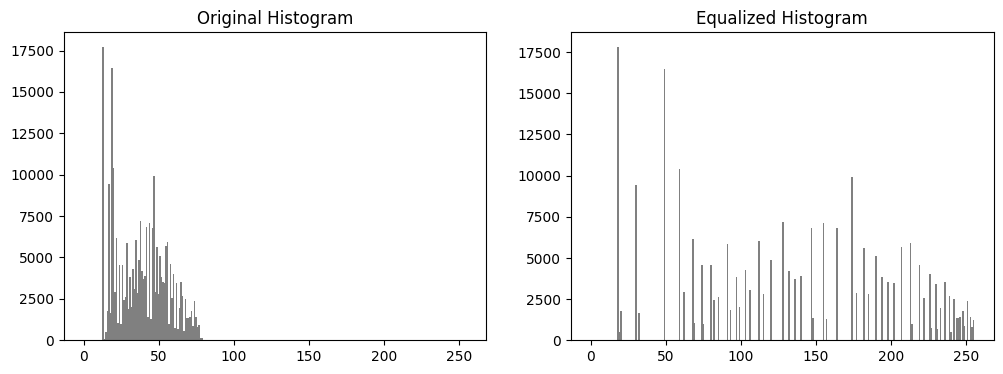

In [19]:
f = cv2.imread('Images/img5.tif', cv2.IMREAD_GRAYSCALE)

M, N = f.shape
L = 256

hist, _ = np.histogram(f, bins=L, range=(0, L))
cdf = np.cumsum(hist)

x = np.array(
    [round((L - 1) / (M * N) * cdf[k]) for k in range(L)],
    dtype=np.uint8
)

y = x[f]

# Original image vs Histogram equalized image
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(y, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Histogram Equalized Image')
ax[1].axis('off')

plt.show()

# Histograms
hist_g, _ = np.histogram(y.ravel(), bins=L, range=(0, L))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(np.arange(L), hist, color='gray', width=1)
ax[0].set_title('Original Histogram')

ax[1].bar(np.arange(L), hist_g, color='gray', width=1)
ax[1].set_title('Equalized Histogram')

plt.show()

**Question 6**

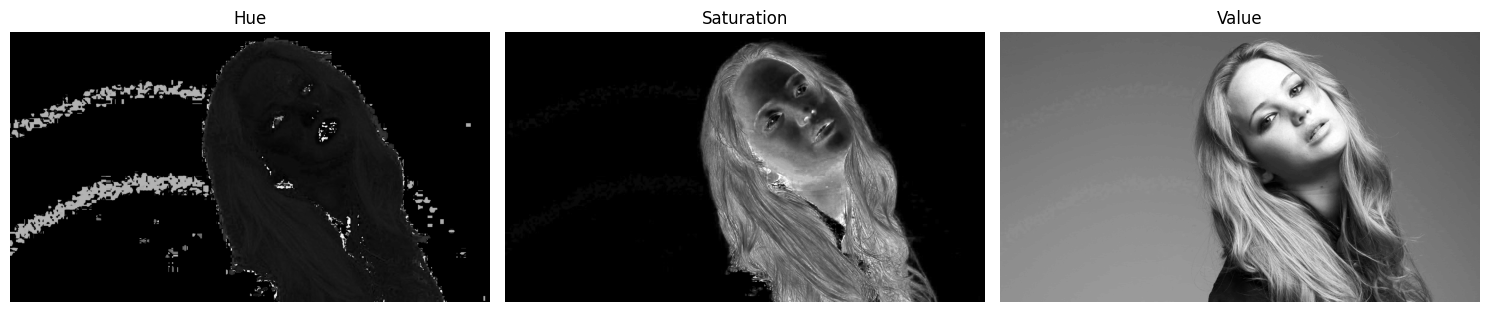

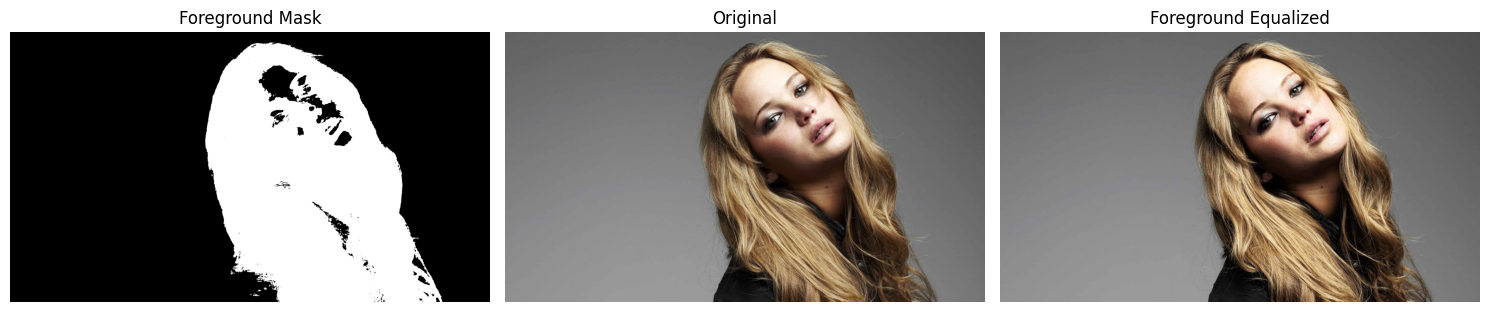

In [27]:
# (a) Split into H, S, V
img = cv2.imread('Images/img6.jpeg', cv2.IMREAD_COLOR)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Plot H, S, V planes
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(h, cmap='gray'); ax[0].set_title('Hue'); ax[0].axis('off')
ax[1].imshow(s, cmap='gray'); ax[1].set_title('Saturation'); ax[1].axis('off')
ax[2].imshow(v, cmap='gray'); ax[2].set_title('Value'); ax[2].axis('off')
plt.tight_layout()
plt.show()

# (b) Select appropriate plane and threshold
_, mask = cv2.threshold(s, 40, 255, cv2.THRESH_BINARY)

# (c) Extract foreground and compute its histogram
foreground = cv2.bitwise_and(img, img, mask=mask)
v_foreground = cv2.bitwise_and(v, v, mask=mask)

# Histogram over foreground pixels only
fg_pixels = v[mask == 255]
hist, _ = np.histogram(fg_pixels, bins=256, range=(0, 256))

# (d) Cumulative sum
cdf = np.cumsum(hist)

# (e) Histogram equalize the foreground
L = 256
MN = fg_pixels.size

t = np.array([round((L - 1) / MN * cdf[k]) for k in range(L)], dtype=np.uint8)
v_eq_foreground = np.where(mask == 255, t[v], 0).astype(np.uint8)

# (f) Extract background and add with equalized foreground
background_mask = cv2.bitwise_not(mask)
v_background = cv2.bitwise_and(v, v, mask=background_mask)

v_result = cv2.add(v_background, v_eq_foreground)

hsv_result = cv2.merge([h, s, v_result])
result = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2BGR)

# Display mask, original, and output images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(mask, cmap='gray'); ax[0].set_title('Foreground Mask'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[1].set_title('Original'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); ax[2].set_title('Foreground Equalized'); ax[2].axis('off')
plt.tight_layout()
plt.show()